In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv(r"C:\Users\User\Documents\Excel Projects\demand_forecasting.csv")
print(df.head().T)

                              0           1           2            3  \
Date                 01-01-2022  01-01-2022  01-01-2022   01-01-2022   
Store ID                   S001        S001        S001         S001   
Product ID                P0001       P0002       P0003        P0004   
Category            Electronics    Clothing    Clothing  Electronics   
Region                    North       North       North        North   
Inventory Level             195         117         247          139   
Units Sold                  102         117         114           45   
Units Ordered               252         249         612          102   
Price                     72.72       80.16       62.94        87.63   
Discount                      5          15          10           10   
Weather Condition         Snowy       Snowy       Snowy        Snowy   
Promotion                     0           1           1            0   
Competitor Pricing        85.73       92.02       60.08        8

In [269]:
#FEATURE ENGINEERING
#Date Parsing and sorting
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)
df=df.sort_values(['Store ID','Category','Region','Date']).reset_index(drop=True)

In [271]:
#Calender features
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Week']=df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']=df['Date'].dt.quarter
df['day_of_week']=df['Date'].dt.dayofweek
df['day_of_year']=df['Date'].dt.dayofyear
df['is_weekend']=(df['day_of_week']>=5).astype(int)
df['is_month_start']=df['Date'].dt.is_month_start.astype(int)
df['is_month_end']=df['Date'].dt.is_month_end.astype(int)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Demand,Year,Month,Week,Quarter,day_of_week,day_of_year,is_weekend,is_month_start,is_month_end
0,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,229,2022,1,52,1,5,1,1,1,0
1,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,157,2022,1,52,1,5,1,1,1,0
2,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,...,129,2022,1,52,1,5,1,1,1,0
3,2022-01-02,S001,P0002,Clothing,North,249,116,0,74.44,10,...,175,2022,1,52,1,6,2,1,0,0
4,2022-01-02,S001,P0003,Clothing,North,133,130,0,66.15,0,...,156,2022,1,52,1,6,2,1,0,0


In [273]:
#Lag features
group_keys=['Store ID','Category','Region']
for lag in [1,7,14,30]:
    df[f"demand_lag_{lag}"]=df.groupby(group_keys)["Demand"].shift(lag)   

In [275]:
#Rolling window features
for window in [7, 14, 30]:
    df[f"demand_rollmean_{window}"] = (
        df.groupby(group_keys)["Demand"]
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f"demand_rollstd_{window}"] = (
        df.groupby(group_keys)["Demand"]
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
    )

df["units_sold_rollmean_7"] = (
    df.groupby(group_keys)["Units Sold"]
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

In [277]:
#Price & Discount features
df['effective_price']=df['Price']*(1-df['Discount']/100)
df['price_gap']=df['Price']-df['Competitor Pricing']
df['price_ratio']=df['Price']/df['Competitor Pricing'].replace(0, np.nan)
df['discount_active']=(df['Discount']>0).astype(int)
df['discount_tier']=pd.cut(df['Discount'],bins=[-1,0,5,10,15,20,25],labels=["none","low","medium","intermediate","high","very high"])

In [279]:
#interaction features
df['promo_discount_interaction']=df['Promotion']*df['Discount']
category_map={"clothing":0,"electronics":1,"furniture":2,"groceries":3,"toys":4}
df['category_encoded_temp']=df['Category'].str.lower().map(category_map)
df['epidemic_category']=df['Epidemic']*df['category_encoded_temp']
season_map = {"spring": 0, "summer": 1, "autumn": 2, "winter": 3}
df["season_encoded_temp"] = df["Seasonality"].str.lower().map(season_map)
df["promo_season_interaction"] = df["Promotion"] * df["season_encoded_temp"]

In [281]:
#Inventory Features
df['stock_gap']=df['Inventory Level']-df['Demand']
df['inventory_coverage']=df['Inventory Level']/df['Demand'].replace(0, np.nan)
df['low_stock_flag']=(df['Inventory Level']<1.5*df['Demand']).astype(int)
df['order_demand_gap']=df['Units Ordered']-df['Demand']

In [283]:
#Delete unnecessary rows and columns
df.drop(columns=["category_encoded_temp", "season_encoded_temp"], inplace=True)

df_clean = df.dropna(subset=[
    "demand_lag_1", "demand_lag_7", "demand_lag_14", "demand_lag_30",
    "demand_rollmean_7", "demand_rollmean_14", "demand_rollmean_30"
]).reset_index(drop=True)

print(f"Rows before: {len(df)}  |  Rows after: {len(df_clean)}")

Rows before: 76000  |  Rows after: 75280


In [285]:
#END OF FEATURE ENGINEERING
#Check missing values
df_clean.isnull().sum()

Date                          0
Store ID                      0
Product ID                    0
Category                      0
Region                        0
Inventory Level               0
Units Sold                    0
Units Ordered                 0
Price                         0
Discount                      0
Weather Condition             0
Promotion                     0
Competitor Pricing            0
Seasonality                   0
Epidemic                      0
Demand                        0
Year                          0
Month                         0
Week                          0
Quarter                       0
day_of_week                   0
day_of_year                   0
is_weekend                    0
is_month_start                0
is_month_end                  0
demand_lag_1                  0
demand_lag_7                  0
demand_lag_14                 0
demand_lag_30                 0
demand_rollmean_7             0
demand_rollstd_7              0
demand_r

In [287]:
#DESCRIPTIVE STATISTICS
#Basic shape
print("Shape:",df_clean.shape)
print("Column Names:",df_clean.columns.tolist())
print("Data Types:",df_clean.dtypes)

Shape: (75280, 48)
Column Names: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Week', 'Quarter', 'day_of_week', 'day_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'demand_lag_1', 'demand_lag_7', 'demand_lag_14', 'demand_lag_30', 'demand_rollmean_7', 'demand_rollstd_7', 'demand_rollmean_14', 'demand_rollstd_14', 'demand_rollmean_30', 'demand_rollstd_30', 'units_sold_rollmean_7', 'effective_price', 'price_gap', 'price_ratio', 'discount_active', 'discount_tier', 'promo_discount_interaction', 'epidemic_category', 'promo_season_interaction', 'stock_gap', 'inventory_coverage', 'low_stock_flag', 'order_demand_gap']
Data Types: Date                          datetime64[ns]
Store ID                              object
Product ID                            object
Category                        

In [289]:
#Descriptive Statistics for numerical columns
print("------------------------Descriptive Stats----------------------")
print(df_clean.describe().T)
print("------------------------Skewness----------------------------")
print(df_clean.skew(numeric_only=True).sort_values(ascending=False))
print("------------------------Kurtosis----------------------------")
print(df_clean.kurt(numeric_only=True).sort_values(ascending=False))

------------------------Descriptive Stats----------------------
                              count                           mean  \
Date                          75280  2023-01-19 01:59:25.185972224   
Inventory Level             75280.0                     301.921599   
Units Sold                  75280.0                      88.897117   
Units Ordered               75280.0                      88.808502   
Price                       75280.0                      67.668889   
Discount                    75280.0                       9.087075   
Promotion                   75280.0                       0.328879   
Competitor Pricing          75280.0                      69.393986   
Epidemic                    75280.0                       0.201913   
Demand                      75280.0                     104.280486   
Year                        75280.0                    2022.564559   
Month                       75280.0                       6.358661   
Week                      

In [291]:
#For Categorical Columns
cat_cols=['Category', 'Region','Weather Condition','Seasonality']
for col in cat_cols:
    print(f"\n{'='*40}")
    print(f"{col.upper()}")
    print(f"{'='*40}")
    vc=df_clean[col].value_counts()
    pct=df_clean[col].value_counts(normalize=True)*100
    summary=pd.DataFrame({'Count': vc,'Percentage %': pct.round(2)})
    print(summary.to_string())
    print(f"\n Unique Values: {df_clean[col].nunique()}")


CATEGORY
             Count  Percentage %
Category                        
Groceries    30250         40.18
Furniture    13530         17.97
Clothing     12010         15.95
Toys         10520         13.97
Electronics   8970         11.92

 Unique Values: 5

REGION
        Count  Percentage %
Region                     
North   30100         39.98
West    15080         20.03
South   15050         19.99
East    15050         19.99

 Unique Values: 4

WEATHER CONDITION
                   Count  Percentage %
Weather Condition                     
Cloudy             24132         32.06
Sunny              22800         30.29
Rainy              17500         23.25
Snowy              10848         14.41

 Unique Values: 4

SEASONALITY
             Count  Percentage %
Seasonality                     
Winter       20280         26.94
Spring       18400         24.44
Summer       18400         24.44
Autumn       18200         24.18

 Unique Values: 4


In [293]:
#Binary Columns
bin_cols=['Promotion','Epidemic','discount_active','low_stock_flag','is_weekend','is_month_start','is_month_end']
for col in bin_cols:
    print(f"\n{'='*40}")
    print(f"{col.upper()}")
    print(f"{'='*40}")
    count=df_clean[col].value_counts()
    pct=df_clean[col].value_counts(normalize=True)*100
    print(pd.DataFrame({'Count': count,'Percentage': pct.round(2)}))


PROMOTION
           Count  Percentage
Promotion                   
0          50522       67.11
1          24758       32.89

EPIDEMIC
          Count  Percentage
Epidemic                   
0         60080       79.81
1         15200       20.19

DISCOUNT_ACTIVE
                 Count  Percentage
discount_active                   
1                58324       77.48
0                16956       22.52

LOW_STOCK_FLAG
                Count  Percentage
low_stock_flag                   
0               54044       71.79
1               21236       28.21

IS_WEEKEND
            Count  Percentage
is_weekend                   
0           53770       71.43
1           21510       28.57

IS_MONTH_START
                Count  Percentage
is_month_start                   
0               72880       96.81
1                2400        3.19

IS_MONTH_END
              Count  Percentage
is_month_end                   
0             72880       96.81
1              2400        3.19


In [295]:
#Demand summary
print(f"Mean: {df_clean['Demand'].mean():.2f}")
print(f"Median: {df_clean['Demand'].median():.2f}")
print(f"Std dev: {df_clean['Demand'].std():.2f}")
print(f"Max: {df_clean['Demand'].max():.2f}")
print(f"Min: {df_clean['Demand'].min():.2f}")
print(f"Skewness: {df_clean['Demand'].skew():.2f}")
print(f"Kurtosis: {df_clean['Demand'].kurt():.2f}")
print("\nAverage Demand by Category:")
print(df_clean.groupby('Category')['Demand'].mean().sort_values(ascending=False).round(2))

print("\nAverage Demand by Region:")
print(df_clean.groupby('Region')['Demand'].mean().sort_values(ascending=False).round(2))

Mean: 104.28
Median: 100.00
Std dev: 47.01
Max: 430.00
Min: 4.00
Skewness: 0.61
Kurtosis: 0.67

Average Demand by Category:
Category
Groceries      120.99
Clothing       112.39
Electronics     97.33
Toys            92.52
Furniture       73.47
Name: Demand, dtype: float64

Average Demand by Region:
Region
South    106.91
East     106.36
North    103.78
West     100.59
Name: Demand, dtype: float64


In [297]:
#Correlation with demand
num_cols=df_clean.select_dtypes(include='number').columns
corr_demand=df_clean[num_cols].corr()['Demand'].drop('Demand')
corr_demand=corr_demand.sort_values(ascending=False)
print("---------Correlation with Demand-----------")
print(corr_demand.round(4))

---------Correlation with Demand-----------
Units Sold                    0.8357
demand_rollmean_14            0.5390
demand_rollmean_30            0.5343
demand_rollmean_7             0.5251
Units Ordered                 0.5127
units_sold_rollmean_7         0.5002
demand_rollstd_30             0.4278
demand_rollstd_14             0.4095
demand_lag_1                  0.3734
demand_rollstd_7              0.3514
low_stock_flag                0.3450
demand_lag_7                  0.3328
demand_lag_14                 0.3179
demand_lag_30                 0.2845
Promotion                     0.2823
promo_discount_interaction    0.2638
order_demand_gap              0.2515
Discount                      0.2244
promo_season_interaction      0.2175
Inventory Level               0.1280
discount_active               0.1097
Month                         0.0442
Week                          0.0431
day_of_year                   0.0427
Quarter                       0.0201
day_of_week                   0

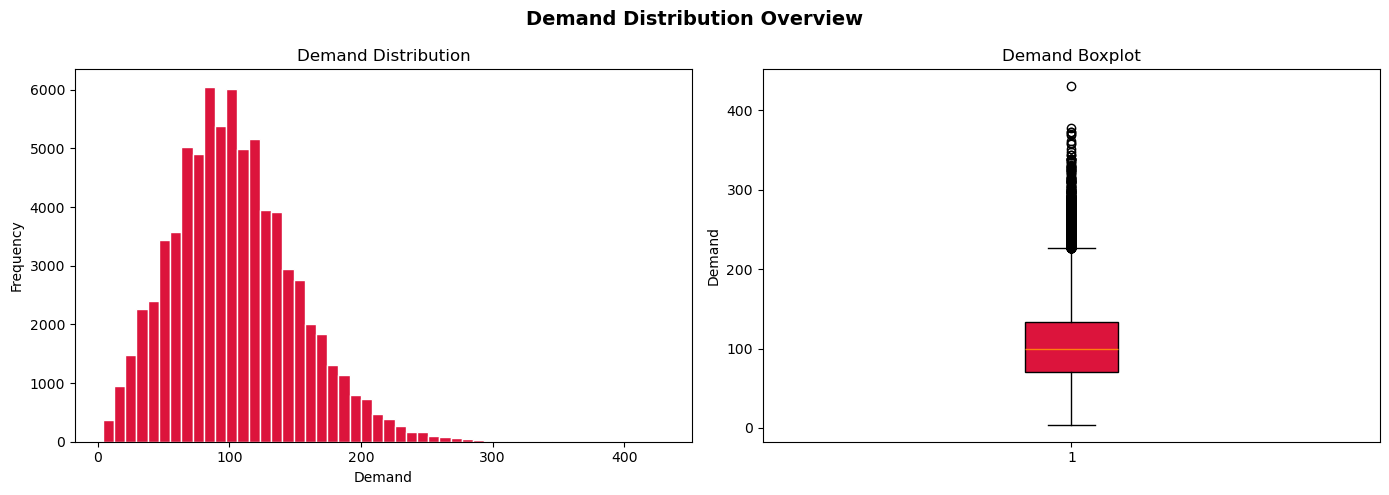

In [299]:
#Demand distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['Demand'], bins=50, color='crimson', edgecolor='white')
axes[0].set_title('Demand Distribution')
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df_clean['Demand'], patch_artist=True,
                boxprops=dict(facecolor='crimson', color='black'))
axes[1].set_title('Demand Boxplot')
axes[1].set_ylabel('Demand')

plt.suptitle('Demand Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

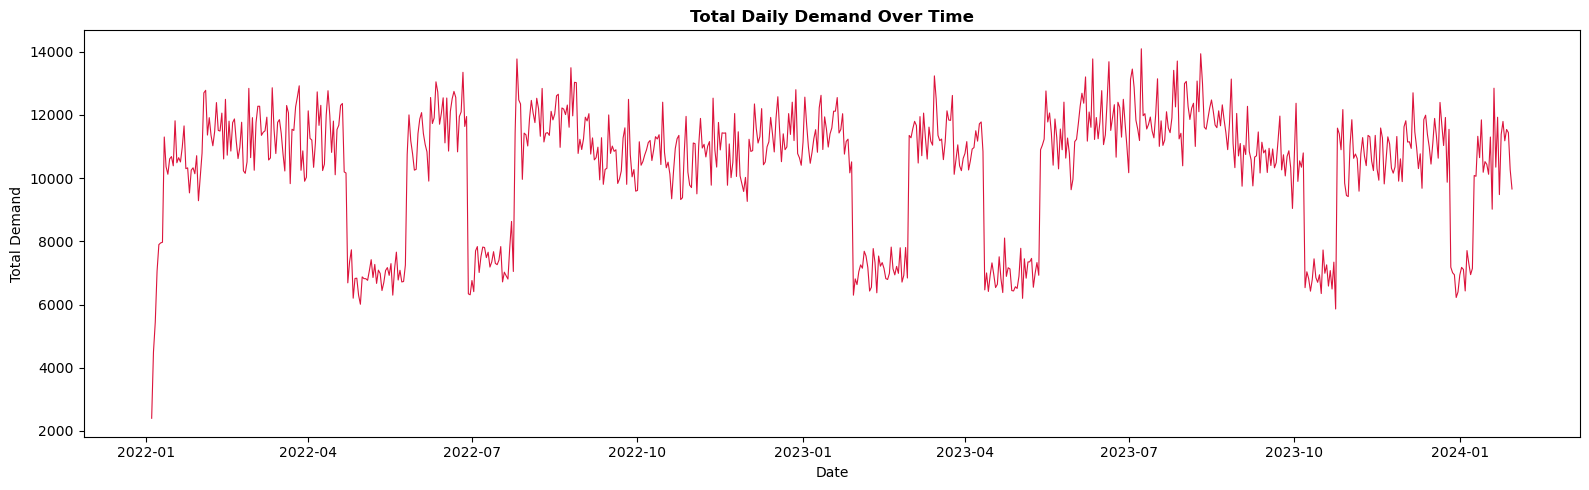

In [301]:
#Demand over time
daily_demand = df_clean.groupby('Date')['Demand'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_demand['Date'], daily_demand['Demand'], color='crimson', linewidth=0.8)
plt.title('Total Daily Demand Over Time', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.tight_layout()
plt.show()

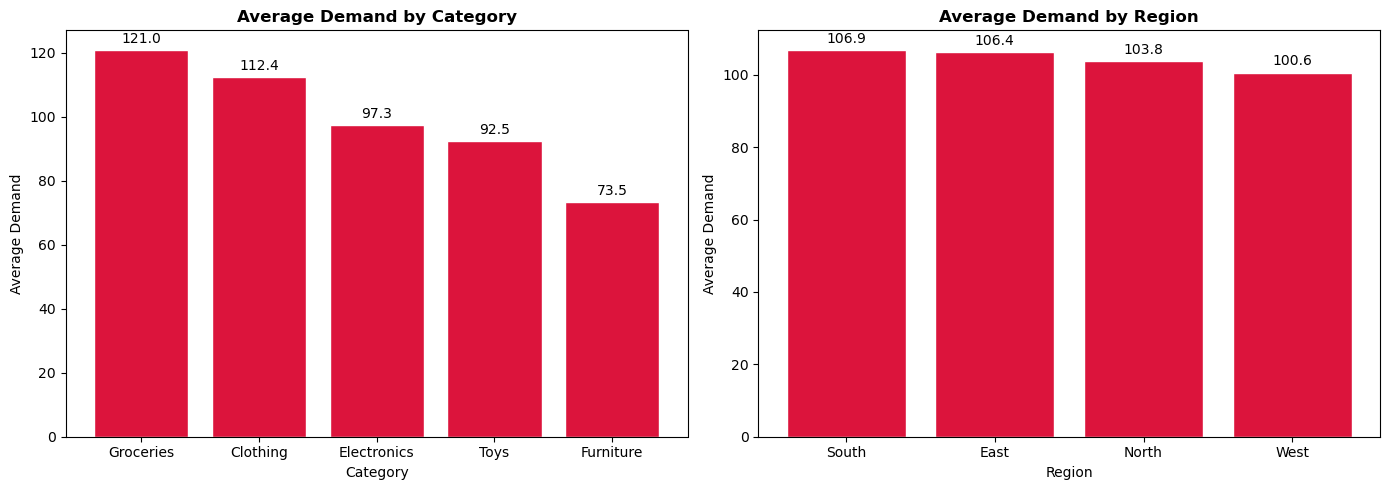

In [303]:
#Demand by category and region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Category
cat_demand = df_clean.groupby('Category')['Demand'].mean().sort_values(ascending=False)
bars = axes[0].bar(cat_demand.index, cat_demand.values, color='crimson', edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f', padding=3)
axes[0].set_title('Average Demand by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Demand')

# By Region
reg_demand = df_clean.groupby('Region')['Demand'].mean().sort_values(ascending=False)
bars = axes[1].bar(reg_demand.index, reg_demand.values, color='crimson', edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f', padding=3)
axes[1].set_title('Average Demand by Region', fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Average Demand')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15352\1935155966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Seasonality', y='Demand',


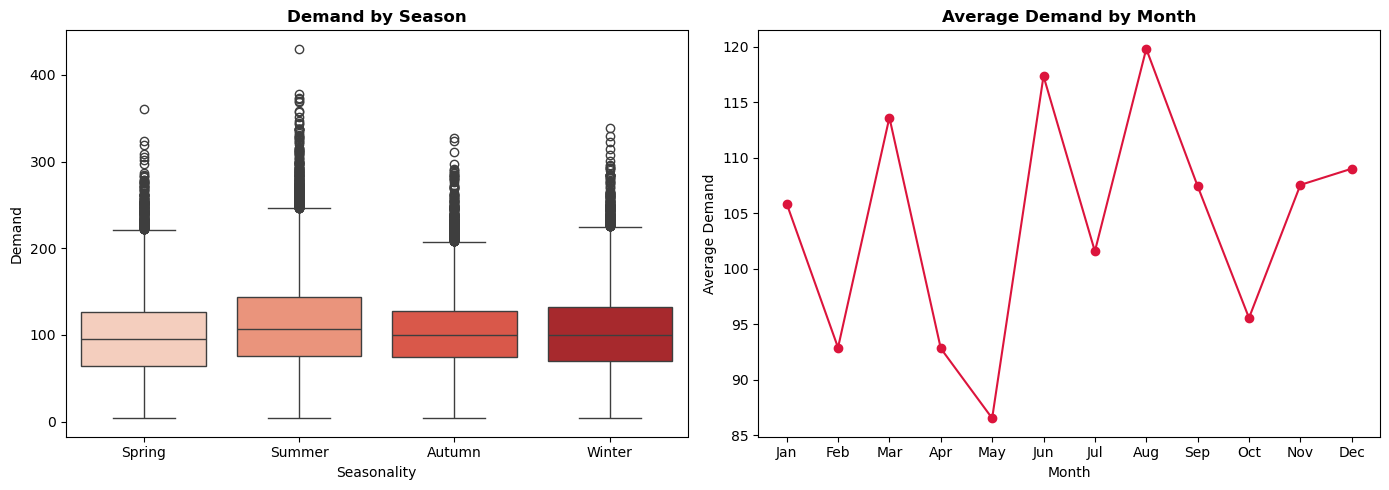

In [305]:
#Seasonal and monthly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Seasonality
sns.boxplot(data=df_clean, x='Seasonality', y='Demand',
            order=['Spring','Summer','Autumn','Winter'],
            palette='Reds', ax=axes[0])
axes[0].set_title('Demand by Season', fontweight='bold')

# By Month
monthly = df_clean.groupby('Month')['Demand'].mean()
axes[1].plot(monthly.index, monthly.values, marker='o', color='crimson')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].set_title('Average Demand by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Demand')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15352\2039077456.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Promotion', y='Demand',
C:\Users\User\AppData\Local\Temp\ipykernel_15352\2039077456.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Promotion', 'Promotion'])
C:\Users\User\AppData\Local\Temp\ipykernel_15352\2039077456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Epidemic', y='Demand',
C:\Users\User\AppData\Local\Temp\ipykernel_15352\2039077456.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of

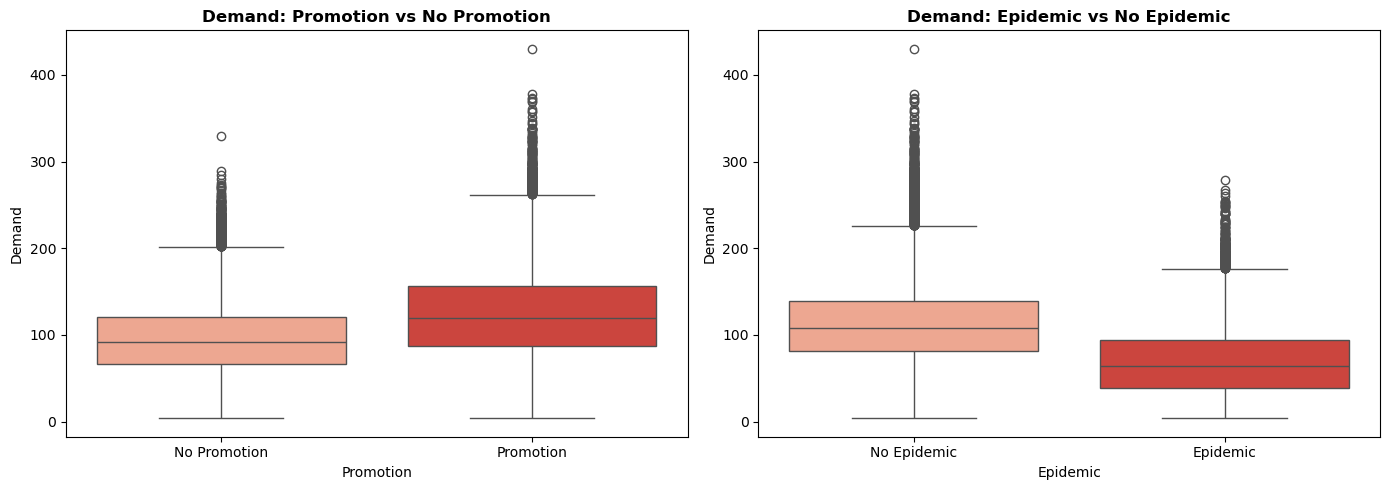

In [307]:
#Promotion and epidemic impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promotion
sns.boxplot(data=df_clean, x='Promotion', y='Demand',
            palette='Reds', ax=axes[0])
axes[0].set_xticklabels(['No Promotion', 'Promotion'])
axes[0].set_title('Demand: Promotion vs No Promotion', fontweight='bold')

# Epidemic
sns.boxplot(data=df_clean, x='Epidemic', y='Demand',
            palette='Reds', ax=axes[1])
axes[1].set_xticklabels(['No Epidemic', 'Epidemic'])
axes[1].set_title('Demand: Epidemic vs No Epidemic', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15352\3953035113.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='discount_tier', y='Demand',


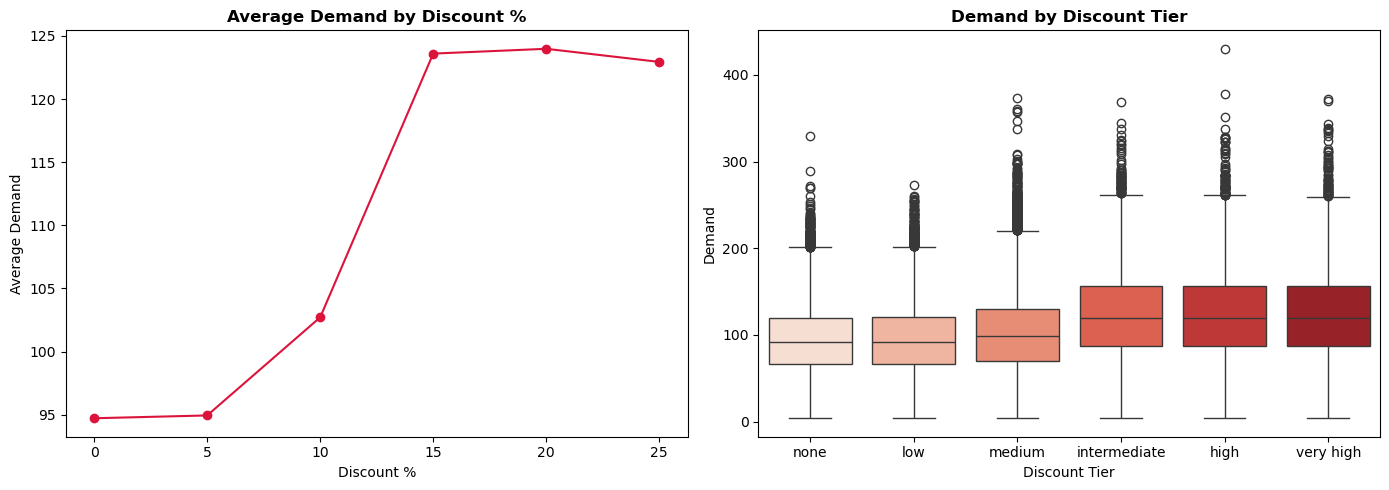

In [309]:
#Discount vs demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average demand per discount level
disc_demand = df_clean.groupby('Discount')['Demand'].mean()
axes[0].plot(disc_demand.index, disc_demand.values, marker='o', color='crimson')
axes[0].set_title('Average Demand by Discount %', fontweight='bold')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Average Demand')

# Boxplot by discount tier
tier_order = ['none', 'low', 'medium', 'intermediate', 'high', 'very high']
sns.boxplot(data=df_clean, x='discount_tier', y='Demand',
            order=tier_order, palette='Reds', ax=axes[1])
axes[1].set_title('Demand by Discount Tier', fontweight='bold')
axes[1].set_xlabel('Discount Tier')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15352\2032253527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Weather Condition', y='Demand', palette='Reds')


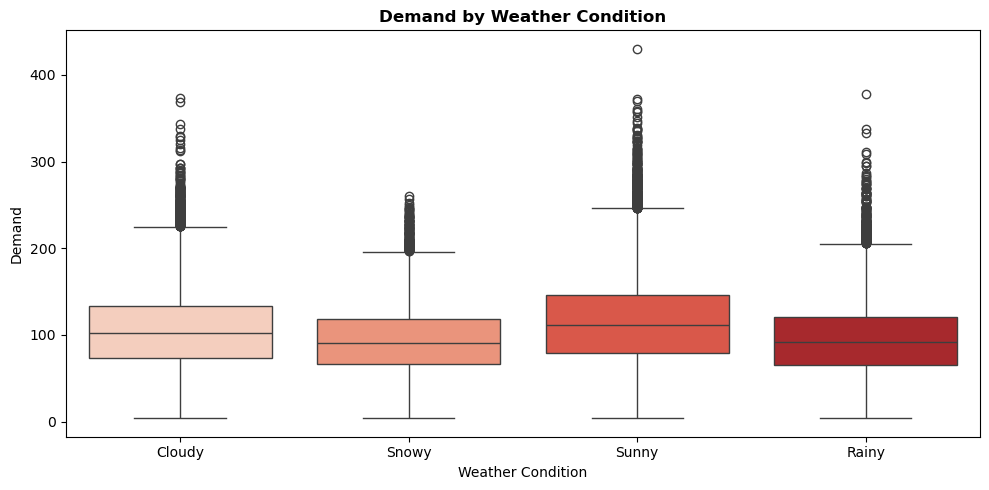

In [311]:
#Weather condition impact
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Weather Condition', y='Demand', palette='Reds')
plt.title('Demand by Weather Condition', fontweight='bold')
plt.xlabel('Weather Condition')
plt.ylabel('Demand')
plt.tight_layout()
plt.show()

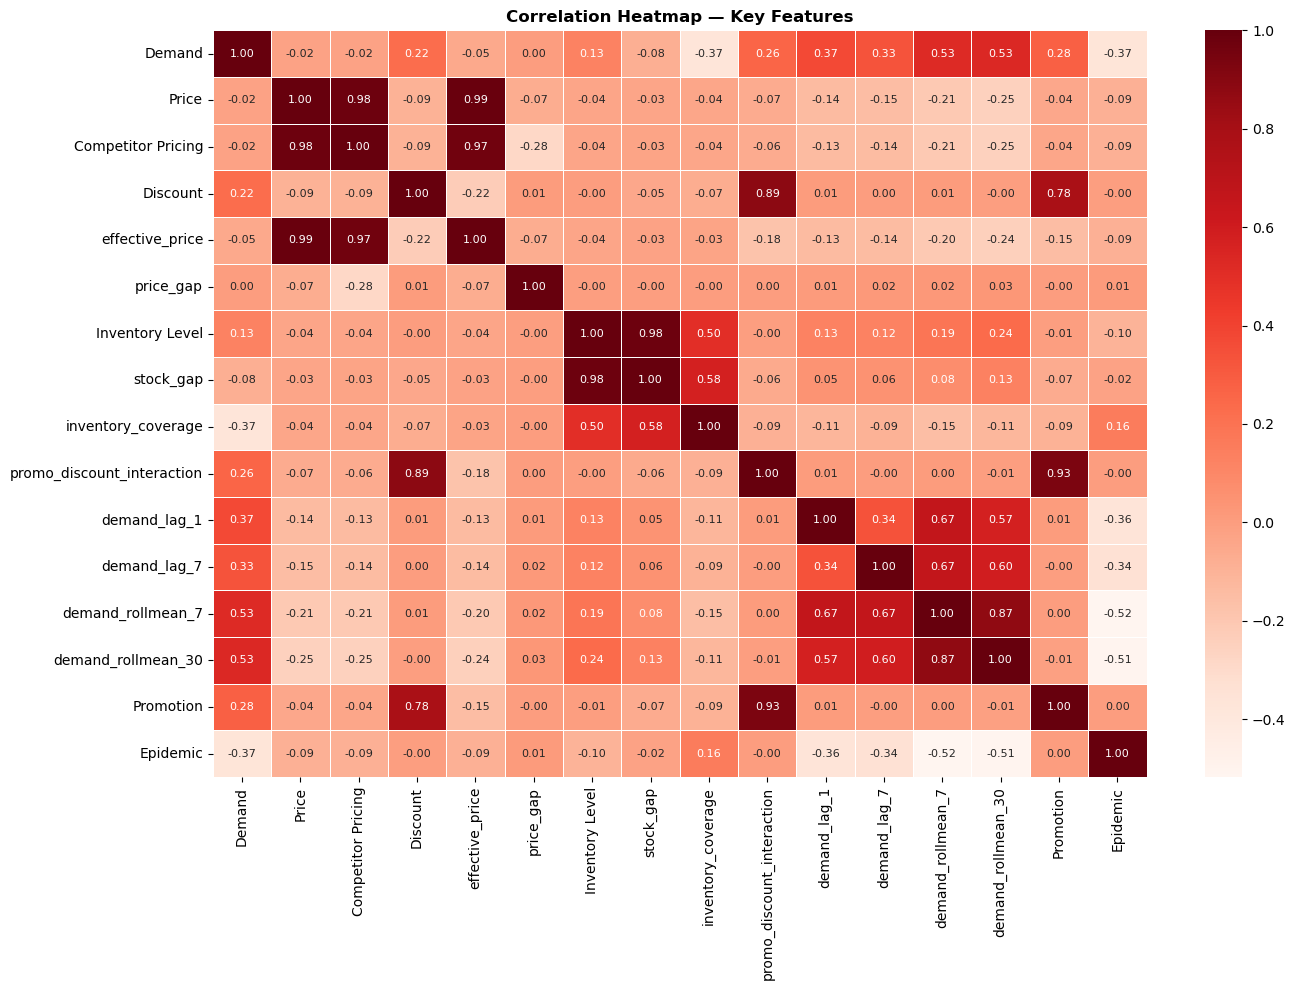

In [313]:
#Correlation impact
# Select key numeric features only — full heatmap gets cluttered
key_cols = ['Demand', 'Price', 'Competitor Pricing', 'Discount',
            'effective_price', 'price_gap', 'Inventory Level',
            'stock_gap', 'inventory_coverage', 'promo_discount_interaction',
            'demand_lag_1', 'demand_lag_7', 'demand_rollmean_7',
            'demand_rollmean_30', 'Promotion', 'Epidemic']

plt.figure(figsize=(14, 10))
corr_matrix = df_clean[key_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Key Features', fontweight='bold')
plt.tight_layout()
plt.show()

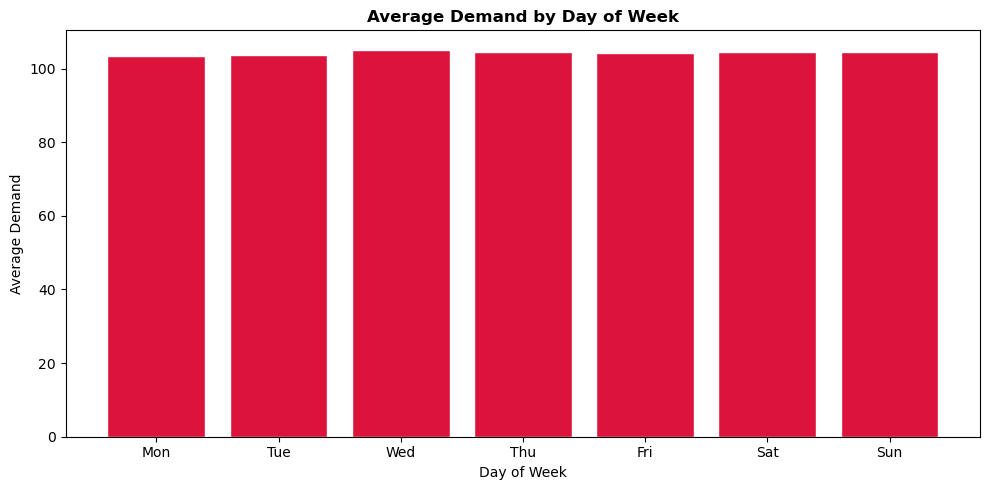

In [315]:
#Demand by day of week
plt.figure(figsize=(10, 5))
dow_demand = df_clean.groupby('day_of_week')['Demand'].mean()
plt.bar(dow_demand.index, dow_demand.values, color='crimson', edgecolor='white')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('Average Demand by Day of Week', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')
plt.tight_layout()
plt.show()

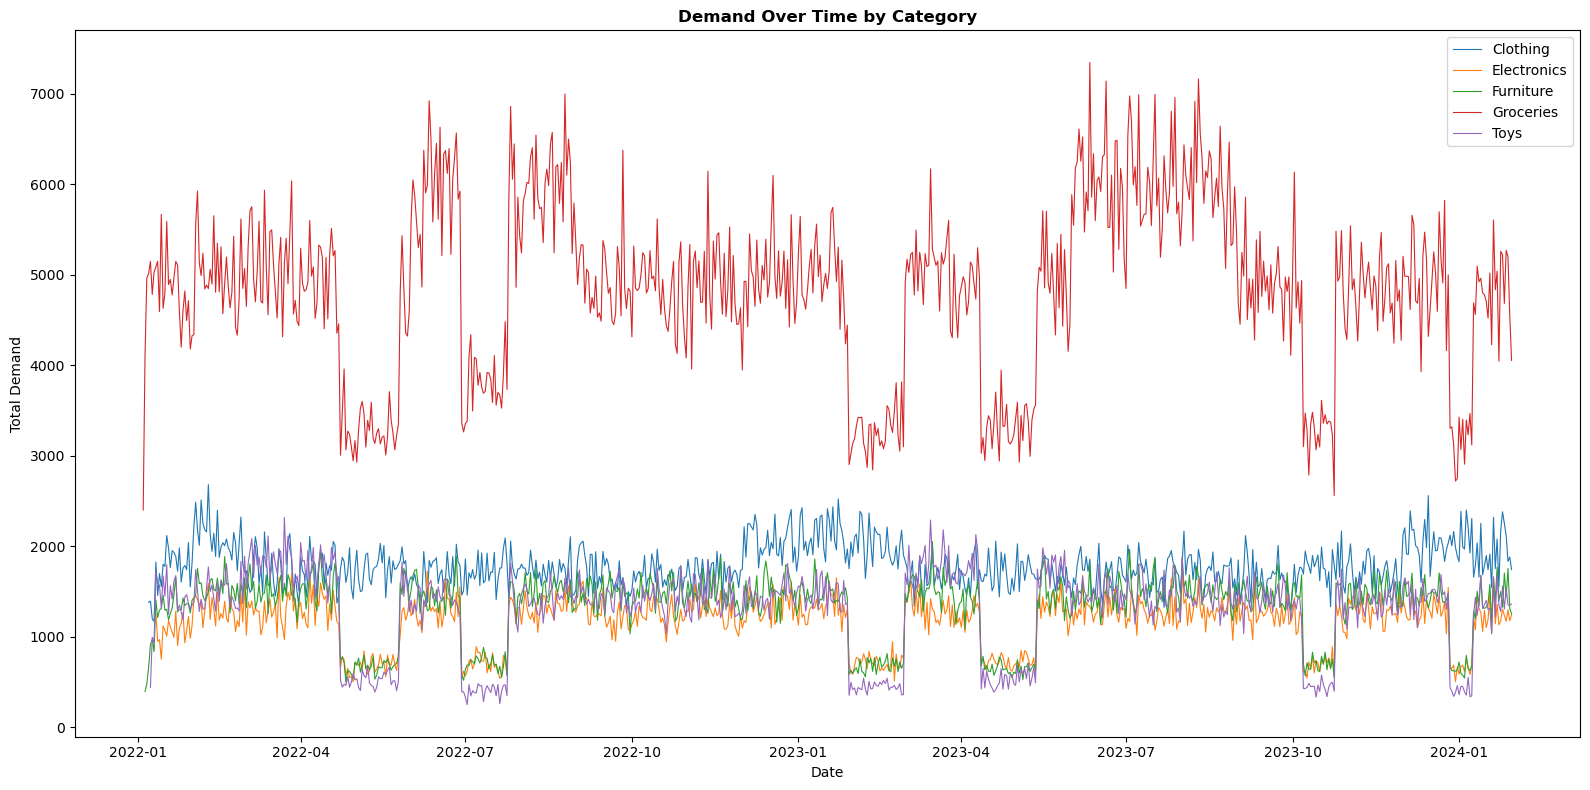

In [317]:
#Category wise demand over time
plt.figure(figsize=(16, 8))
for category in df_clean['Category'].unique():
    cat_data = df_clean[df_clean['Category'] == category].groupby('Date')['Demand'].sum()
    plt.plot(cat_data.index, cat_data.values, label=category, linewidth=0.8)

plt.title('Demand Over Time by Category', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.legend()
plt.tight_layout()
plt.show()

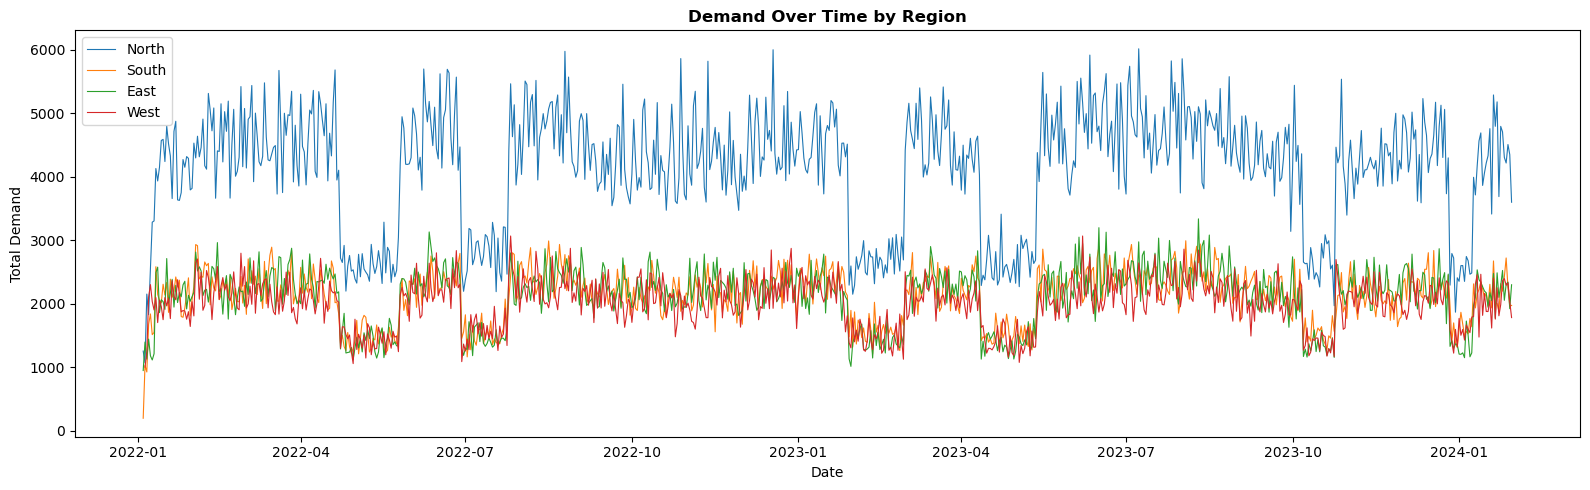

In [319]:
#Region-wise demand over time
plt.figure(figsize=(16, 5))
for region in df_clean['Region'].unique():
    reg_data = df_clean[df_clean['Region'] == region].groupby('Date')['Demand'].sum()
    plt.plot(reg_data.index, reg_data.values, label=region, linewidth=0.8)

plt.title('Demand Over Time by Region', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.legend()
plt.tight_layout()
plt.show()

In [333]:
#SARIMAX
#Libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
#Aggregation of demand by category + date
cat_demand=(df_clean.groupby(['Date','Category'])['Demand'].sum().reset_index())
#Aggregation of exogenous variables by category+date
exog_cols=['Promotion','Epidemic','Discount']
cat_exog_demand=(df_clean.groupby(['Date','Category'])[exog_cols].sum().reset_index())
#Split per category
categories=df_clean['Category'].unique()
train_data={}
test_data={}
train_exog={}
test_exog={}
for cat in categories:
    #Demand series
    cat_df=cat_demand[cat_demand['Category']==cat].set_index('Date').sort_index()
    train_data[cat]=cat_df.loc[:'2023-12-31','Demand']
    test_data[cat]=cat_df.loc['2024-01-01':,'Demand']
    #Exogenous series
    cat_exog_df=cat_exog_demand[cat_exog_demand['Category']==cat].set_index('Date').sort_index()
    train_exog[cat]=cat_exog_df.loc[:'2023-12-31',exog_cols]
    test_exog[cat]=cat_exog_df.loc['2024-01-01':,exog_cols]
#Verify slpit
print("Train test split")
print("="*45)
for cat in categories:
    print(f"\n{cat}")
    print(f"  Train → {train_data[cat].index.min().date()} "
          f"to {train_data[cat].index.max().date()} "
          f"({len(train_data[cat])} days)")
    print(f"  Test  → {test_data[cat].index.min().date()} "
          f"to {test_data[cat].index.max().date()} "
          f"({len(test_data[cat])} days)")

Train test split

Clothing
  Train → 2022-01-07 to 2023-12-31 (724 days)
  Test  → 2024-01-01 to 2024-01-30 (30 days)

Electronics
  Train → 2022-01-11 to 2023-12-31 (720 days)
  Test  → 2024-01-01 to 2024-01-30 (30 days)

Furniture
  Train → 2022-01-05 to 2023-12-31 (726 days)
  Test  → 2024-01-01 to 2024-01-30 (30 days)

Groceries
  Train → 2022-01-04 to 2023-12-31 (727 days)
  Test  → 2024-01-01 to 2024-01-30 (30 days)

Toys
  Train → 2022-01-08 to 2023-12-31 (723 days)
  Test  → 2024-01-01 to 2024-01-30 (30 days)


In [349]:
#Stationarity Check function
def check_stationarity(series, category):
    print(f"\n{'='*45}")
    print(f"{category.upper()}")
    print(f"{'='*45}")
    #ADF test
    adf_result=adfuller(series,autolag='AIC')
    print(f"\n  ADF Test:")
    print(f"    ADF Statistic : {adf_result[0]:.4f}")
    print(f"    p-value       : {adf_result[1]:.4f}")
    print(f"    Result        : {'✅ Stationary' if adf_result[1] < 0.05 else '❌ Non-Stationary'}")
    #KPSS test
    kpss_result=kpss(series,regression='c',nlags='auto')
    print(f"\n  KPSS Test:")
    print(f"    KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"    p-value       : {kpss_result[1]:.4f}")
    print(f"    Result        : {'❌ Non-Stationary' if kpss_result[1] < 0.05 else '✅ Stationary'}")
#Run for all categories
print("Stationary checks- original series")
for cat in categories:
    check_stationarity(train_data[cat],cat)

Stationary checks- original series

CLOTHING

  ADF Test:
    ADF Statistic : -4.1631
    p-value       : 0.0008
    Result        : ✅ Stationary

  KPSS Test:
    KPSS Statistic: 0.1542
    p-value       : 0.1000
    Result        : ✅ Stationary

ELECTRONICS

  ADF Test:
    ADF Statistic : -4.6954
    p-value       : 0.0001
    Result        : ✅ Stationary

  KPSS Test:
    KPSS Statistic: 0.0647
    p-value       : 0.1000
    Result        : ✅ Stationary

FURNITURE

  ADF Test:
    ADF Statistic : -5.0292
    p-value       : 0.0000
    Result        : ✅ Stationary

  KPSS Test:
    KPSS Statistic: 0.0641
    p-value       : 0.1000
    Result        : ✅ Stationary

GROCERIES

  ADF Test:
    ADF Statistic : -3.6203
    p-value       : 0.0054
    Result        : ✅ Stationary

  KPSS Test:
    KPSS Statistic: 0.1003
    p-value       : 0.1000
    Result        : ✅ Stationary

TOYS

  ADF Test:
    ADF Statistic : -5.2349
    p-value       : 0.0000
    Result        : ✅ Stationary

  KP

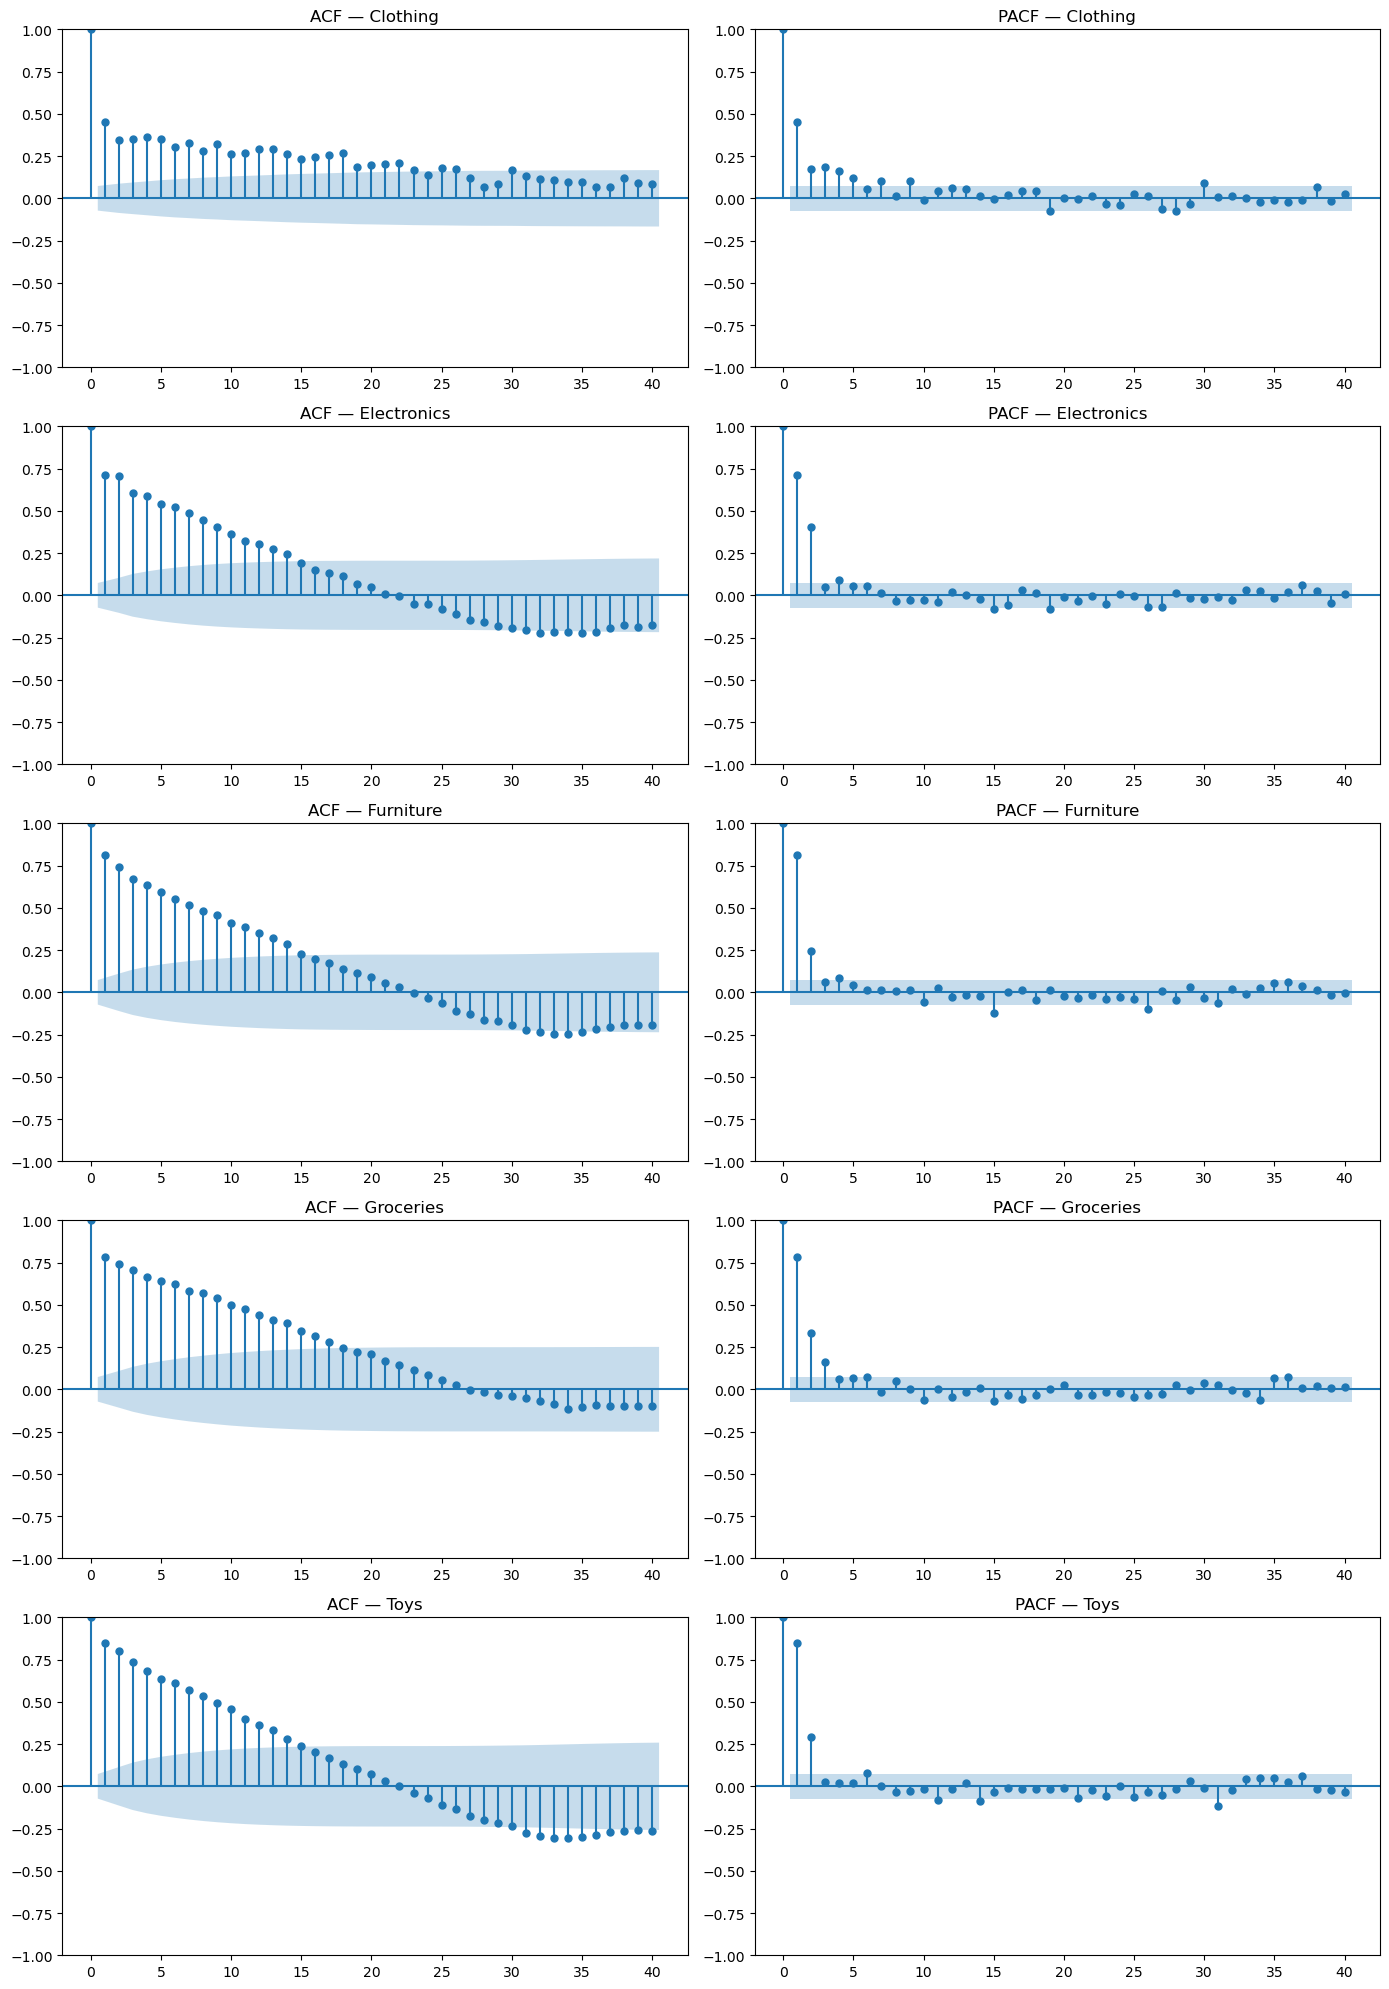

In [351]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, cat in enumerate(categories):
    plot_acf(train_data[cat], lags=40, ax=axes[i][0], title=f'ACF — {cat}')
    plot_pacf(train_data[cat], lags=40, ax=axes[i][1], title=f'PACF — {cat}')

plt.tight_layout()
plt.show()

In [353]:
#Fit SARIMAX MODEL
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = {}

for cat in categories:
    print(f"\n{'='*45}")
    print(f"  Fitting SARIMAX — {cat.upper()}")
    print(f"{'='*45}")
    
    model = SARIMAX(
        train_data[cat],
        exog=train_exog[cat],
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    fitted = model.fit(disp=False)
    results[cat] = fitted
    print(fitted.summary())


  Fitting SARIMAX — CLOTHING
                                     SARIMAX Results                                     
Dep. Variable:                            Demand   No. Observations:                  724
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5095.372
Date:                           Tue, 09 Jun 2026   AIC                          10206.743
Time:                                   15:36:47   BIC                          10243.322
Sample:                               01-07-2022   HQIC                         10220.869
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Promotion   -118.4453     12.663     -9.354      0.000    -143.264     -93.626
Epidemic     

In [355]:
#Forecast
forecasts = {}

for cat in categories:
    forecast = results[cat].forecast(
        steps=len(test_data[cat]),
        exog=test_exog[cat]
    )
    forecasts[cat] = forecast
    print(f"✅ Forecast done — {cat}")

✅ Forecast done — Clothing
✅ Forecast done — Electronics
✅ Forecast done — Furniture
✅ Forecast done — Groceries
✅ Forecast done — Toys


In [357]:
#Evaluate
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100

print("\n" + "="*55)
print("  SARIMAX FORECAST EVALUATION")
print("="*55)
print(f"{'Category':<15} {'MAE':>8} {'RMSE':>10} {'MAPE%':>10}")
print("-"*55)

for cat in categories:
    actual    = test_data[cat].values
    predicted = forecasts[cat].values
    
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape_val = np.mean(np.abs((actual - predicted) / 
               np.where(actual == 0, np.nan, actual))) * 100
    
    print(f"{cat:<15} {mae:>8.2f} {rmse:>10.2f} {mape_val:>9.2f}%")

print("="*55)


  SARIMAX FORECAST EVALUATION
Category             MAE       RMSE      MAPE%
-------------------------------------------------------
Clothing          231.10     267.24     11.69%
Electronics       177.70     214.53     18.20%
Furniture         176.83     221.58     15.51%
Groceries         561.19     659.44     12.81%
Toys              172.34     209.75     18.78%


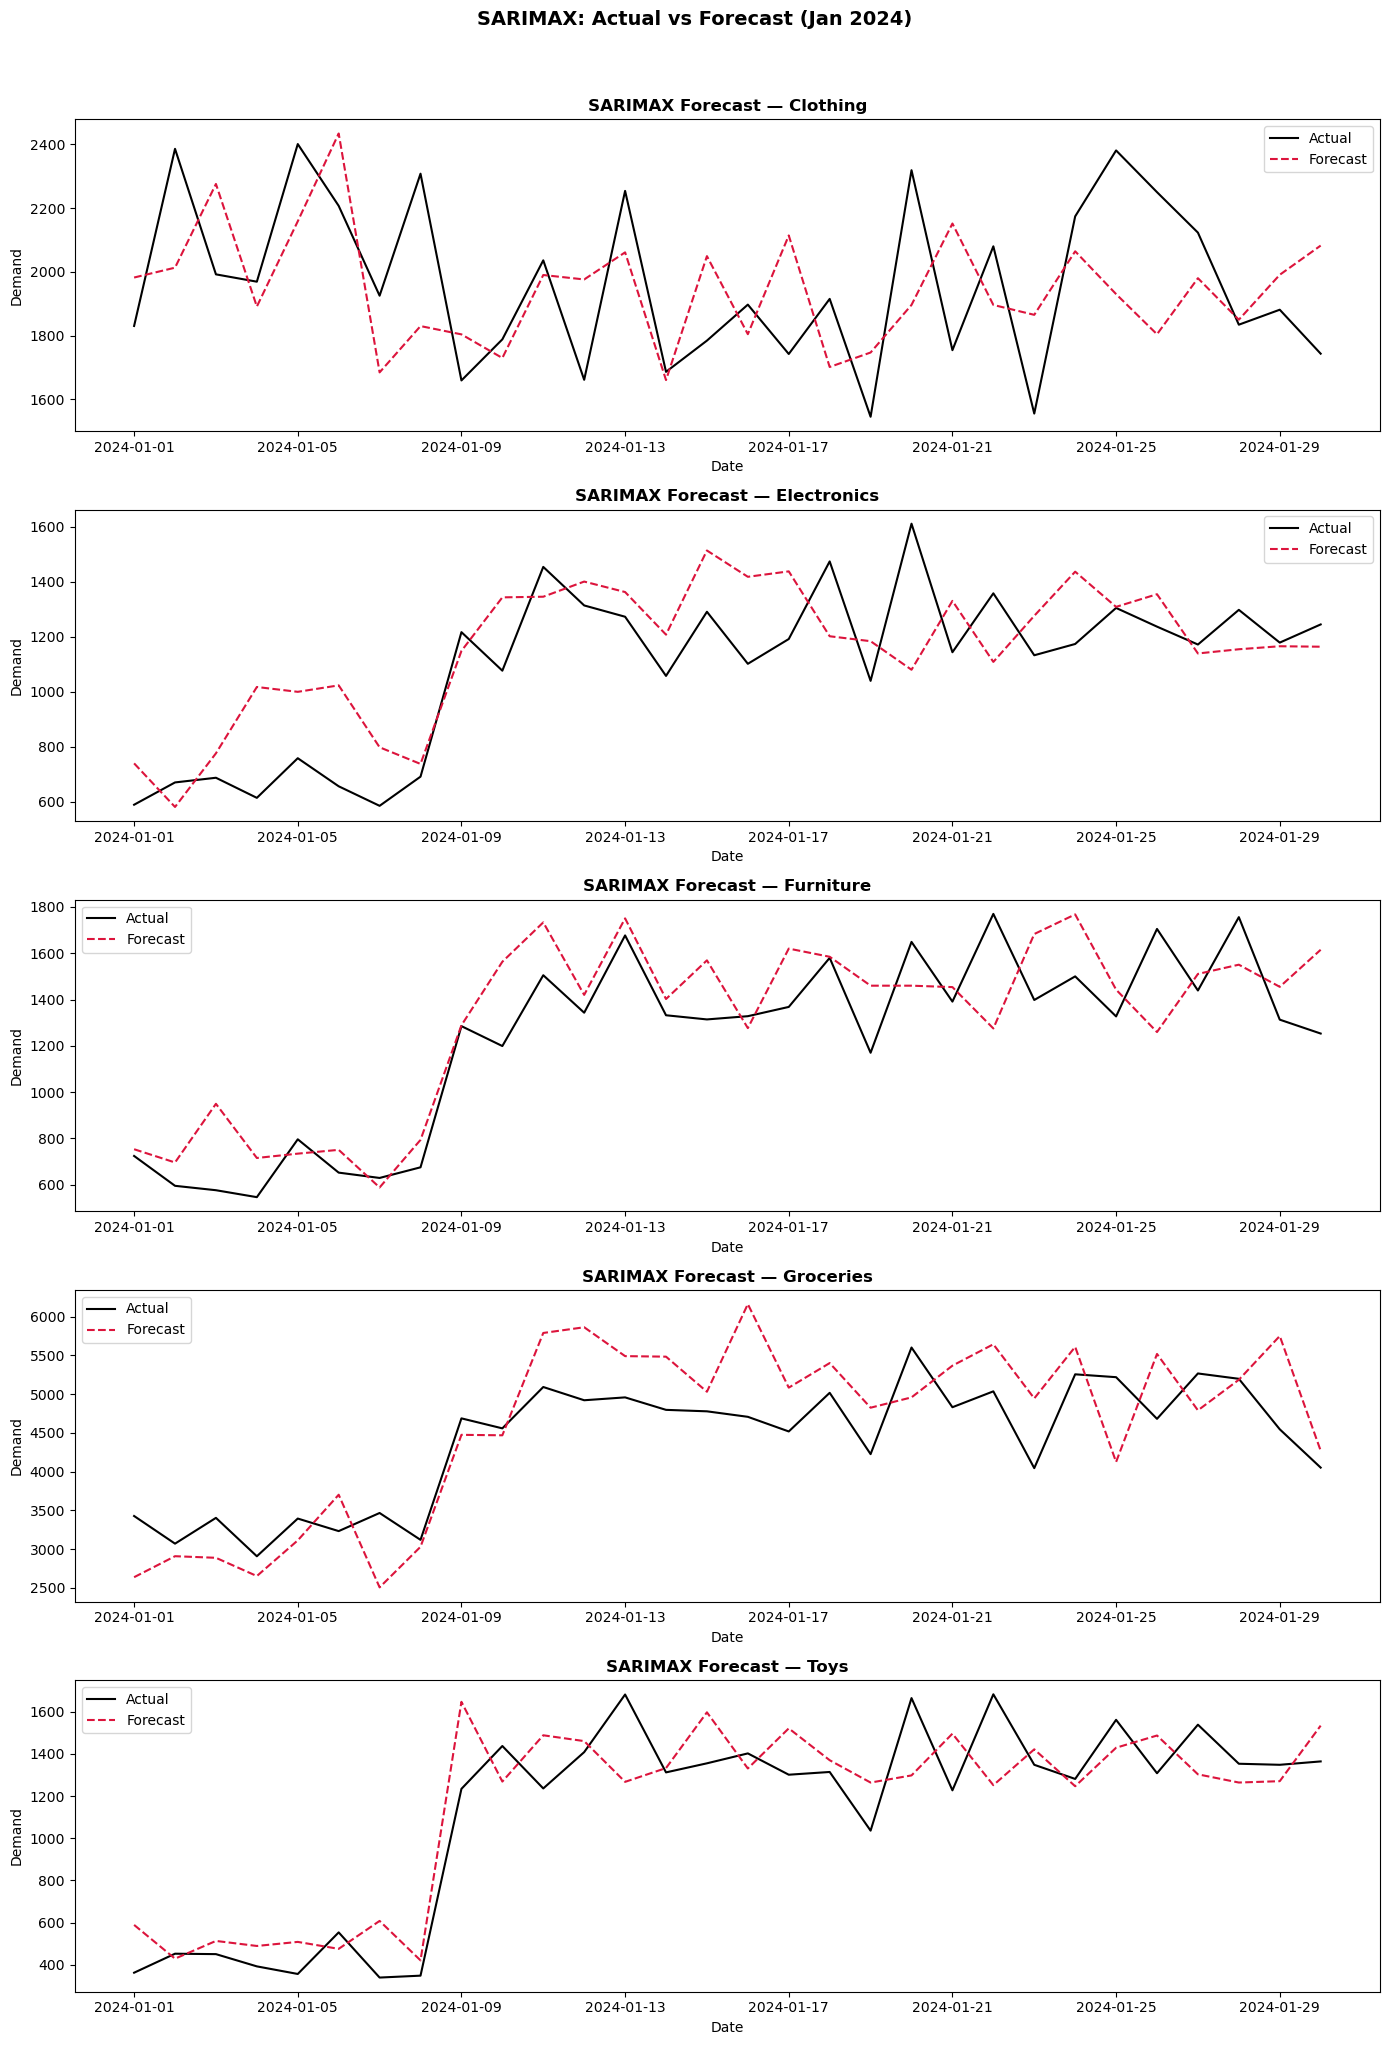

In [361]:
#Forecast vs Actual
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for i, cat in enumerate(categories):
    axes[i].plot(test_data[cat].index, test_data[cat].values,
                 label='Actual', color='black', linewidth=1.5)
    axes[i].plot(forecasts[cat].index, forecasts[cat].values,
                 label='Forecast', color='crimson', 
                 linewidth=1.5, linestyle='--')
    axes[i].set_title(f'SARIMAX Forecast — {cat}', fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Demand')
    axes[i].legend()

plt.suptitle('SARIMAX: Actual vs Forecast (Jan 2024)', 
             fontsize=14, fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()